# Atoms repeatedly traversing a cavity
## Quantistic simulation of a Cavity QED System and Trapping States 

**Informatics Tools Exam** - **Student:** Cecilia Bertolini - **Date:** September 2026

### 1. Theoric Introduction and Physic Model
This project analyses the time evolution of a magnetic field inside an optical cavity initially in the vacuum state ($\vert 0 \rangle$), interacting with a sequence of two level atoms prepared in the excited state ($\vert e \rangle$). The system is described by the **Jaynes-Cummings model** at resonance.
Cavity leakage ($\kappa = 0$) and spontaneous decay of the atom ($\gamma = 0$) are assumed to be negligible. The product of the interaction time $T_{\text{int}}$ and the coupling $g$ can be varied between simulations.

### State after the interaction with the first atom
After the first atom passes through the cavity, the system evolves in the entangled state:
$$|\psi(T_{\text{int}})\rangle = \cos(g T_{\text{int}}) |e, 0\rangle - i \sin(g T_{\text{int}}) |g, 1\rangle$$

### 2. Derivation of the recursive relation
In the derivation of the probability $P_m(n)$ of finding $n$ photons inside the cavity after the passagge of $m$ atoms, two mutually exclusive processes are considered starting from $m-1$:
1. The cavity initially contains $n$ photons and the atom passes through without emitting any photons, with probability proportional to $\cos^2(g T_{\text{int}}\sqrt{n+1})$.
2. The cavity initially contains $n-1$ photons and the atom undergoes stimulated emission, decaying to the ground state $\vert{}g\rangle$, with probability proportional to $\sin^2(g T_{\text{int}}\sqrt{n})$.
Considering these two processes, we obtain the following recursive relation: 
$P_m(n) = \cos^2(g T_{\text{int}}\sqrt{n+1})P_{m-1}(n) + \sin^2(g T_{\text{int}}\sqrt{n})P_{m-1}(n-1)$

**Computational Note:** The implementation of the recursive relation in Python gives a <font color="red">'RecursionError'</font> crash due to a stack memory overflow when $m=1000$. To solve this problem the algorithm is implemented using **Dynamic Programming (Bottom-Up)**.


In [84]:
import numpy as np
import matplotlib.pyplot as plt

# Define function to compute the probability distribution using Dynamic Programming to prevent stack overflow 
def compute_photon_distribution(m_max, gT=0.45):
    P_current = np.zeros(m_max + 1) # IC : m=0 atoms -> 0 photons with probability equal to 1.0
    P_current[0] = 1.0 # At most m photons after m atoms have passed through the cavity

    # Create dictionary where to save the requested results 
    target_m = [2, 5, 30, 100, 1000]
    saved_distributions = {} 

    # Iterative calculation
    for m in range(1, m_max + 1):
        P_next = np.zeros(m_max + 1)
        for n in range(m + 1):
            cos_term = np.cos(gT * np.sqrt(n + 1))**2 * P_current[n]
            sin_term = np.sin(gT * np.sqrt(n))**2 * P_current[n - 1] if n > 0 else 0.0 # No negative indices

            P_next[n] = cos_term + sin_term

        P_current = P_next

        if m in target_m:
            saved_distributions[m] = P_current.copy() # Save requested results (deep copy of data)

    return saved_distributions

# Parameters
gT = 0.45 
ms = [2, 5, 30, 100, 1000] # List of requested m values
distributions = compute_photon_distribution(1000, gT)

In [85]:
# Check the probability conservation
for m in ms:
    P_n = distributions[m]
    prob_sum = np.sum(P_n)
    n_peak = np.argmax(P_n)
    peak_value = P_n[n_peak]
    print(f"Per m = {m:4d} -> Somma P(n): {prob_sum:.6f} | Picco massimo a n = {n_peak} (Valore: {peak_value:.4f})")


Per m =    2 -> Somma P(n): 1.000000 | Picco massimo a n = 0 (Valore: 0.6574)
Per m =    5 -> Somma P(n): 1.000000 | Picco massimo a n = 0 (Valore: 0.3504)
Per m =   30 -> Somma P(n): 1.000000 | Picco massimo a n = 23 (Valore: 0.1195)
Per m =  100 -> Somma P(n): 1.000000 | Picco massimo a n = 39 (Valore: 0.2460)
Per m = 1000 -> Somma P(n): 1.000000 | Picco massimo a n = 47 (Valore: 0.6620)


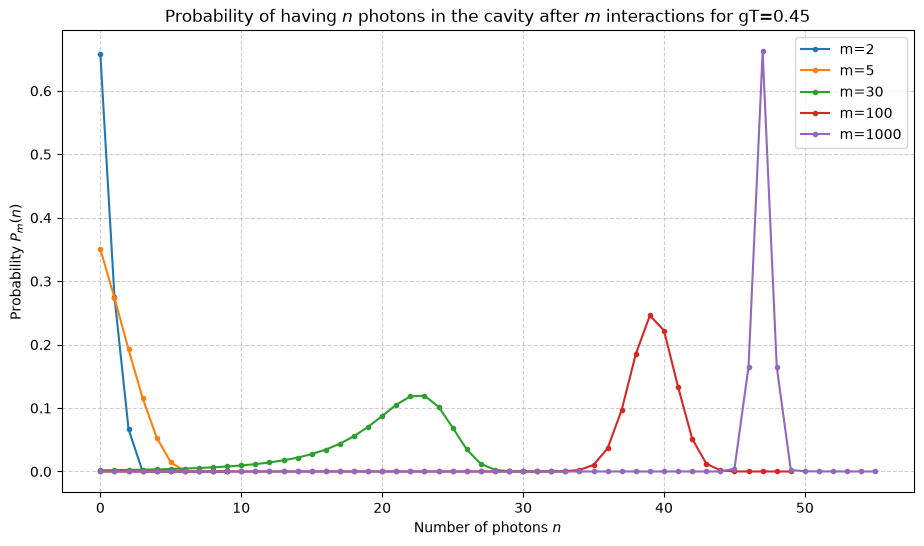

In [86]:
plt.figure(figsize=(11, 6), dpi=100)
for m in ms:
    P_n = distributions[m]
    max_n_to_show = max(int(np.max(np.where(P_n > 1e-4))) + 5, 10) # Display just the significant portion of the plot (prob > 1e-4)
    n_axis = np.arange(max_n_to_show) 

    plt.plot(n_axis, P_n[:max_n_to_show], label=f'm={m}', marker='o', markersize=3)

plt.xlabel('Number of photons $n$')
plt.ylabel('Probability $P_m(n)$')
plt.title(f'Probability of having $n$ photons in the cavity after $m$ interactions for gT={gT}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 3. Results and Discussion, Trapping States
The analysis of the graphs shows strongly non-classical behaviours:

1. **Initial Evolution ($m = 2, 5, 30$):** The distribution progressively shifts to the right. The expectation value of the number of photons increases coherently with the stimulated emission induced by the excited atoms, which transfer energy to the cavity field.
2. **Emergence of the narrow peak ($m = 100, 1000$):** The shifting towards the right is not indefinite (as would be in the case of a classic laser), the distribution eventually halts and pinches into a very high and narrow peak.
3. **Physic explanation of the "Quantum Wall":** This phenomenon is caused by the existence of a **Trapping State**. The atomic transition probability is governed by the term $\sin^2(g T_{\text{int}}\sqrt{n})$. When the number of photons satisfies the condition:
$$ g T_{\text{int}}\sqrt{n_{\text{trap}}} \approx \pi $$
the sine argument makes the emission probability go to zero. Substituting the value $ g T_{\text{int}} = 0.45 $ we can analitically  derive the barrier: 
$$\sqrt{n_{\text{trap}}} \approx \frac{\pi}{0.45} \approx 6.98 \implies n_{\text{trap}} \approx 48.7 \implies n = 49$$

At $n = 49$, the atom-field Rabi oscillations frequency is perfectly tuned with the interaction time $T_{\text{int}}$. The atom enters being in the exicted state, undergoes a complete oscillation and exits the cavity being again in the excited state, without emitting other photons.

For $m = 1000$ the high number of interactions forces almost all the statistical trajectories of the system to collapse and accumulate against the quantum wall, generating a sub-Poissonian state of the field with a really low quantistic uncertainty (quasi-Fock state).

#### Interaction Time $T_{\text{int}}$ and coupling $g$

Varying the product of the interaction time and the coupling the position of the quantum wall is shifted:
1. Increasing $g T_{\text{int}}$ (*e.g.:* from 0.45 to 0.60): the interaction between atoms is stronger and longer lasting. The peak shifts to the left, towards lower values of $n$.
2. Decreasing $g T_{\text{int}}$ (*e.g.:* from 0.45 to 0.20): the coupling is weak, many more photons are needed to force the atom to complete one Rabi oscillation before it exits the cavity. The peak shifts to the right, towards higher values of $n$.

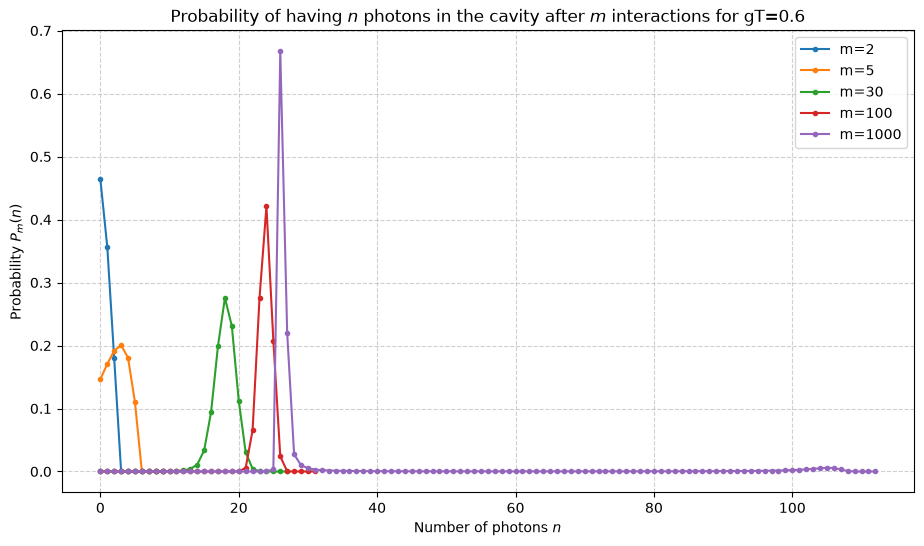

Position of the quantum wall: 27.0


In [92]:
gT = float(input("Insert coupling gT: ")) # Ask for coupling value
ms = [2, 5, 30, 100, 1000] # List of requested m values
distributions = compute_photon_distribution(1000, gT)
plt.figure(figsize=(11, 6), dpi=100)
for m in ms:
    P_n = distributions[m]
    max_n_to_show = max(int(np.max(np.where(P_n > 1e-4))) + 5, 10) # Display just the significant portion of the plot (prob > 1e-4)
    n_axis = np.arange(max_n_to_show) 

    plt.plot(n_axis, P_n[:max_n_to_show], label=f'm={m}', marker='o', markersize=3)

plt.xlabel('Number of photons $n$')
plt.ylabel('Probability $P_m(n)$')
plt.title(f'Probability of having $n$ photons in the cavity after $m$ interactions for gT={gT}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

n_trap = (np.pi/gT)**2
print("Position of the quantum wall:", np.round(n_trap))